# CO$_2$ - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_co2_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[336.22 336.504 336.788 ... 344.55 344.15500000000003 344.56] [336.22 336.504 336.788 ... 342.1666666666667 343.36333333333334 344.56] [336.22 336.69800000000004 337.17600000000004 ... 343.1425 343.885 344.56] [336.22 336.5040000000001 338.08333333333337 ... 343.21 343.9525 344.56] [336.22 336.504 336.788 ... 343.2775 344.02000000000004 344.56] [336.22 336.504 336.78800000000007 ... 343.44392857142856 344.0875 344.56]] [[336.58 336.903 337.226 ... 344.92 344.41 344.18] [336.58 336.903 337.226 ... 340.59333333333336 342.38666666666666 344.18] [336.58 337.066 337.55199999999996 ... 342.87857142857143 343.62714285714287 344.18] [336.58 336.903 338.6766666666667 ... 343.07428571428574 343.8228571428571 344.18] [336.58 336.90299999999996 337.226 ... 343.27 344.0185714285714 344.18] [336.58 336.903 337.22599999999994 ... 343.70142857142855 344.21428571428567 344.18]] [[336.92 337.21500000000003 337.51 ... 342.05 342.99000000000007 343.34] [336.92 337.21500000000003 337.51000000000005 ... 338.09333333333336 340.71666666666664 343.34] [336.92 337.466 338.012 ... 341.56642857142856 342.5128571428571 343.34] [336.92 337.21500000000003 338.86 ... 341.6857142857143 342.63214285714287 343.34] [336.92 337.21500000000003 337.51 ... 341.805 342.7514285714286 343.34] [336.92 337.21500000000003 337.51 ... 342.44642857142856 342.8707142857143 343.34]] ... [[417.73 417.86 417.9075 ... 420.67 418.685 418.535] [417.73 417.87 417.38 ... 420.1666666666667 419.28833333333336 418.41] [417.73 417.72833333333335 417.7266666666667 ... 418.43 418.5 418.66] [417.73 417.83 417.62 ... 420.7866666666667 421.5 418.91] [417.73 417.84000000000003 417.8875 ... 421.02000000000004 421.34000000000003 418.785] [417.73 417.85 417.89750000000004 ... 423.77 420.01250000000005 418.66]] [[417.885 417.9375 418.0375 ... 426.1 424.59 423.175] [417.885 417.93 417.2 ... 424.4866666666666 423.83333333333337 423.18] [417.885 418.20416666666665 418.52333333333337 ... 422.81 423.44 423.17] [417.885 417.96 417.58 ... 427.2833333333333 425.83 423.16] [417.885 417.9525 418.0525 ... 424.66 424.99571428571426 423.165] [417.885 417.945 418.04499999999996 ... 426.8314285714286 424.7928571428572 423.17]] [[417.99 417.795 417.97 ... 428.0 427.665 426.0875] [417.99 417.73 416.89 ... 426.54499999999996 426.2775 426.01] [417.99 418.40000000000003 418.81 ... 425.18 425.795 426.16499999999996] [417.99 417.99 417.53 ... 430.6466666666667 428.48333333333335 426.32] [417.99 417.925 418.1 ... 427.06333333333333 428.12928571428574 426.2425] [417.99 417.86 418.03499999999997 ... 429.9385714285715 427.89714285714285 426.16499999999996]]]
Units,ppm


### Drop out any years that have nan

These break everything later on

In [8]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    local.xarray_time.convert_time_to_year_month(interpolated_spatial).dropna("year")
)
interpolated_spatial_nan_free

Magnitude,[[[337.85 337.92 338.08 ... 417.73 417.885 417.99] [337.44296296296295 337.457037037037 337.63481481481483 ... 417.86 417.9375 417.795] [338.0077777777778 338.4222222222222 338.7688888888889 ... 417.9075 418.0375 417.97] ... [344.11 345.15 345.85 ... 420.67 426.1 428.0] [344.73500000000007 345.68500000000006 345.40999999999997 ... 418.685 424.59 427.665] [344.36 345.11 345.8 ... 418.535 423.175 426.0875]] [[337.85 337.92 338.08 ... 417.73 417.885 417.99] [337.2 337.1 337.24 ... 417.87 417.93 417.73] [337.9858333333333 338.07666666666665 338.3416666666667 ... 417.38 417.2 416.89] ... [342.27333333333337 343.67 344.31333333333333 ... 420.1666666666667 424.4866666666666 426.54499999999996] [343.31666666666666 344.39 345.0566666666667 ... 419.28833333333336 423.83333333333337 426.2775] [344.36 345.11 345.8 ... 418.41 423.18 426.01]] [[337.85 337.92 338.08 ... 417.73 417.885 417.99] [338.142 338.16 338.356 ... 417.72833333333335 418.20416666666665 418.40000000000003] [338.434 338.40000000000003 338.63199999999995 ... 417.7266666666667 418.52333333333337 418.81] ... [341.9889285714286 343.2546428571429 344.69399999999996 ... 418.43 422.81 425.18] [343.34785714285715 344.3492857142857 345.49800000000005 ... 418.5 423.44 425.795] [344.36 345.11 345.8 ... 418.66 423.17 426.16499999999996]] [[337.85 337.92 338.08 ... 417.73 417.885 417.99] [338.17185185185184 338.5281481481482 338.81925925925924 ... 417.83 417.96 417.99] [338.7366666666667 339.49333333333334 339.9533333333333 ... 417.62 417.58 417.53] ... [342.3357142857143 343.58857142857147 345.296 ... 420.7866666666667 427.2833333333333 430.6466666666667] [343.69464285714287 344.6832142857143 346.0 ... 421.5 425.83 428.48333333333335] [344.36 345.11 345.8 ... 418.91 423.16 426.32]] [[337.85 337.92 338.08 ... 417.73 417.885 417.99] [337.9288888888889 338.17111111111114 338.4244444444444 ... 417.84000000000003 417.9525 417.925] [338.4937037037037 339.13629629629634 339.5585185185185 ... 417.8875 418.0525 418.1] ... [342.6825 343.9225 345.3266666666667 ... 421.02000000000004 424.66 427.06333333333333] [344.0414285714286 345.01714285714286 345.80333333333334 ... 421.34000000000003 424.99571428571426 428.12928571428574] [344.36 345.11 345.8 ... 418.785 423.165 426.2425]] [[337.85 337.92 338.08 ... 417.73 417.885 417.99] [337.6859259259259 337.8140740740741 338.0296296296296 ... 417.85 417.945 417.86] [338.25074074074075 338.7792592592593 339.16370370370373 ... 417.89750000000004 418.04499999999996 418.03499999999997] ... [343.25178571428575 344.4946428571428 345.13 ... 423.77 426.8314285714286 429.9385714285715] [344.3882142857143 345.35107142857146 345.6066666666667 ... 420.01250000000005 424.7928571428572 427.89714285714285] [344.36 345.11 345.8 ... 418.66 423.17 426.16499999999996]]]
Units,ppm


### Longitudinal-mean

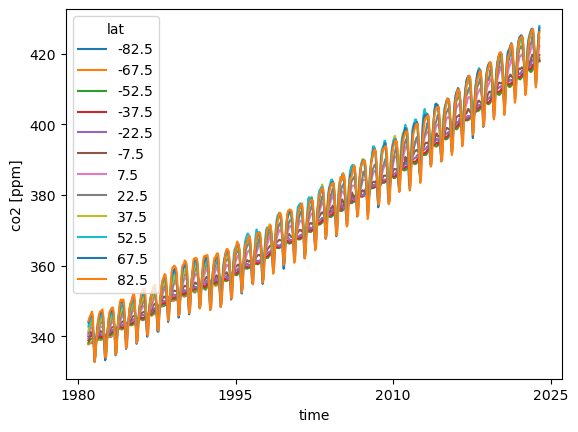

In [9]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

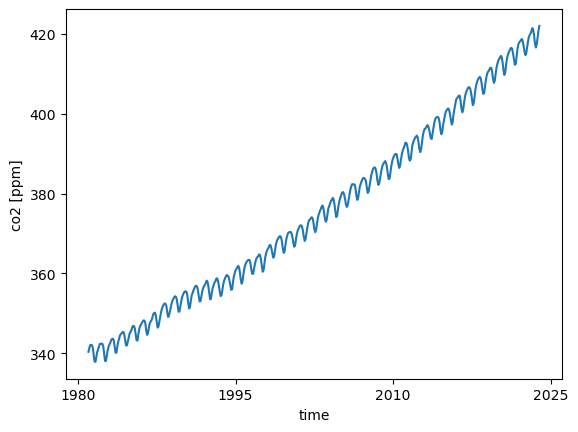

In [10]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

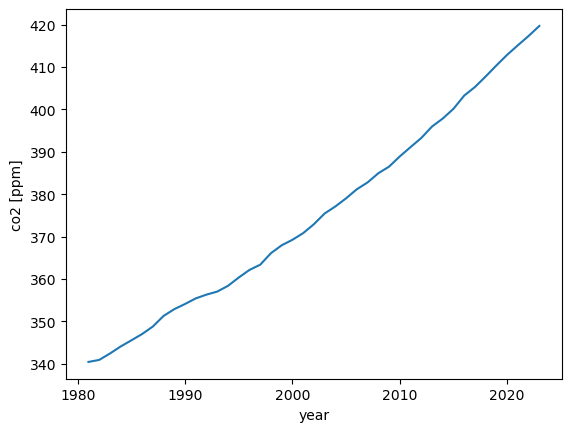

In [11]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [12]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 6kB
Dimensions:               (lat: 12, eof: 12, year: 43)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 344B 1981 1982 1983 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppm] 0.3399 -0.228 ... 0.05329
    principal-components  (year, eof) float64 4kB [] -3.408 1.373 ... -3.056e-14

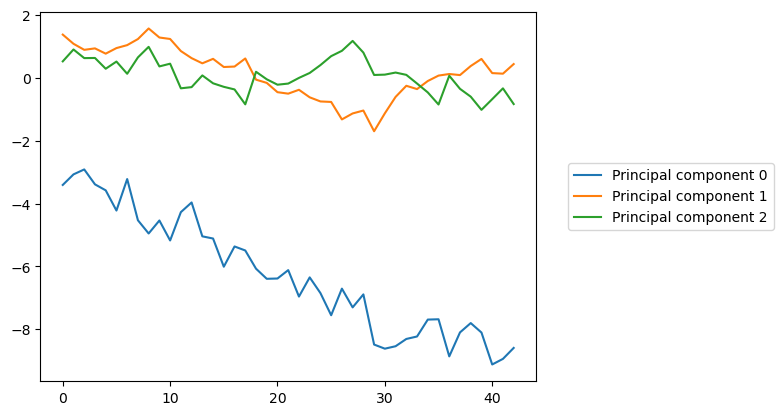

In [13]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

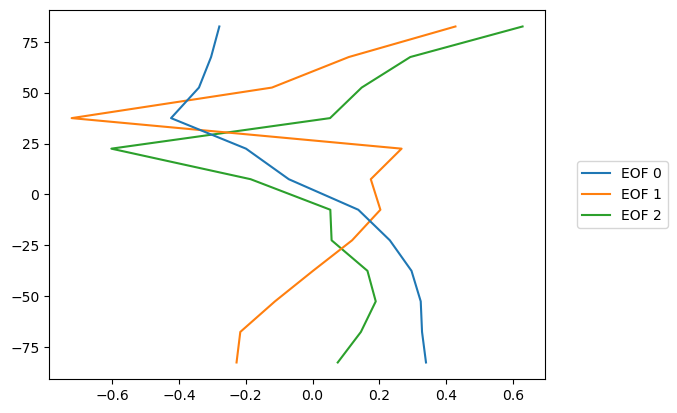

In [14]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

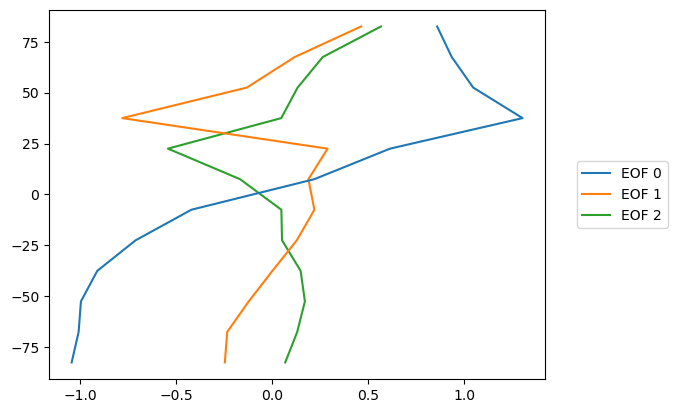

In [15]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [16]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3398549235667994 -0.2279518542202384] [0.3280249642550779 -0.21667814452529127] [0.3240928653441622 -0.11290118149536105] [0.29643637000091805 0.001162345511583901] [0.23146558727475253 0.11844135697646926] [0.13696989509884952 0.20319759722792471] [-0.0713614960427211 0.174397046007536] [-0.19958442222557185 0.2667222315807009] [-0.4242643004612816 -0.7221899732016387] [-0.34060660505423995 -0.12186793264806786] [-0.3042778672164788 0.10852869951757736] [-0.279510277857286 0.42811117709708046]]
Units,ppm
Magnitude,[[-3.4078559757362656 1.3728705809672521] [-3.0718928926968796 1.080944204165597] [-2.9148521501787985 0.8886287181528333] [-3.389224313579394 0.9345832823250398] [-3.5797363227564327 0.7671336820172274] [-4.222134676615504 0.9441732209243293] [-3.220898661371553 1.0383549537628198] [-4.531214183272495 1.2310945088122962] [-4.951772992913496 1.5677083013287625] [-4.538514865693663 1.2804213657427] [-5.173706470749861 1.2338640592569938] [-4.273103707637795 0.8496375674941062] [-3.965108611258437 0.6241795767995816] [-5.042210471999207 0.459726569836758] [-5.111975184252345 0.6019809645460302] [-6.008421371790536 0.3424537649315777] [-5.36418297137572 0.35681607952608585] [-5.492211705600382 0.6138119587480596] [-6.070957788177195 -0.059653030130348075] [-6.392679427617976 -0.16228148585739732] [-6.3834000533068505 -0.45827770761568964] [-6.116260991320756 -0.5048325325708336] [-6.957893832419071 -0.3820759214669319] [-6.347658054708406 -0.6213875357467776] [-6.846471859965717 -0.7524881659932885] [-7.551205937839135 -0.7686209282608008] [-6.705257602735117 -1.3241931223382695] [-7.301377545919926 -1.1342376935890761] [-6.888449225143301 -1.0418218293248094] [-8.483601605052062 -1.7004306283376365] [-8.614714835190084 -1.1307825171650858] [-8.537130218880705 -0.6086678103421533] [-8.305819625835335 -0.2548015726615268] [-8.226966271201903 -0.3595563980313965] [-7.689675133590265 -0.10292169544148298] [-7.679706725149857 0.06957983323397103] [-8.859902121453993 0.11975459474699837] [-8.09737915282875 0.08563958690373405] [-7.8006602845076145 0.37368035213824286] [-8.101679825965508 0.5991512005844014] [-9.1172598635361 0.14862754294515435] [-8.939469815800466 0.1303478895442889] [-8.590944383639819 0.4360138174509567]]
Units,dimensionless


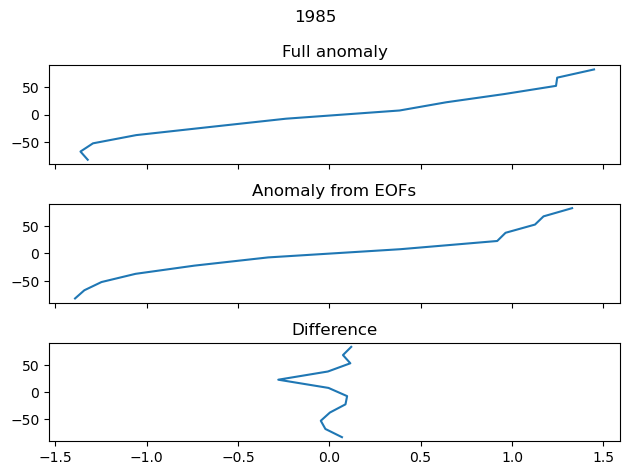

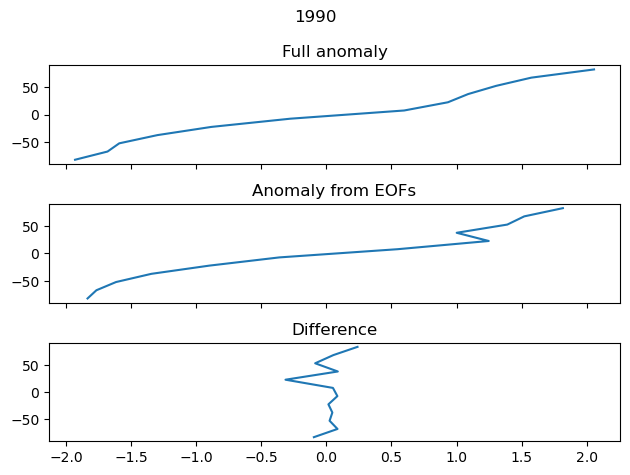

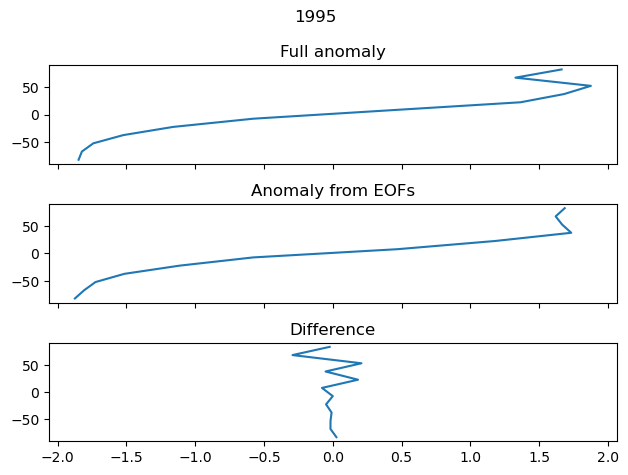

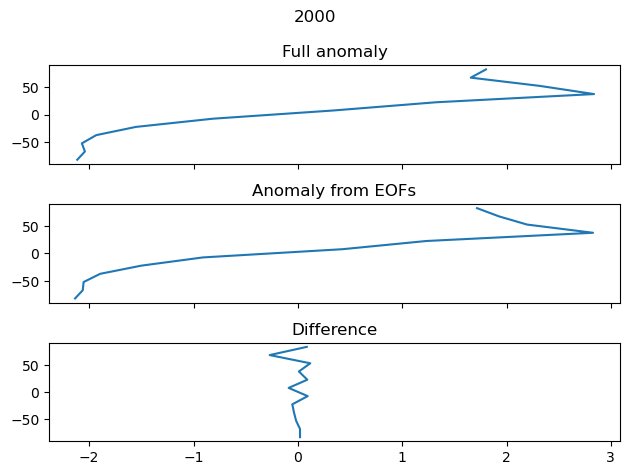

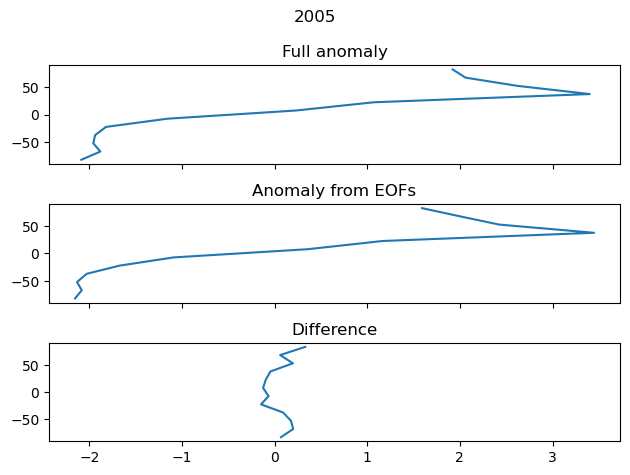

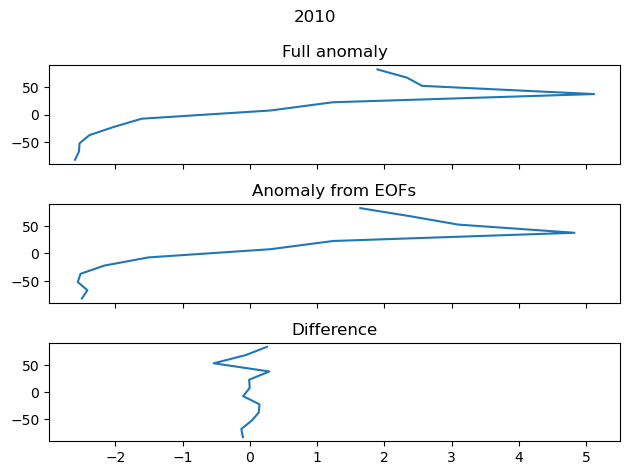

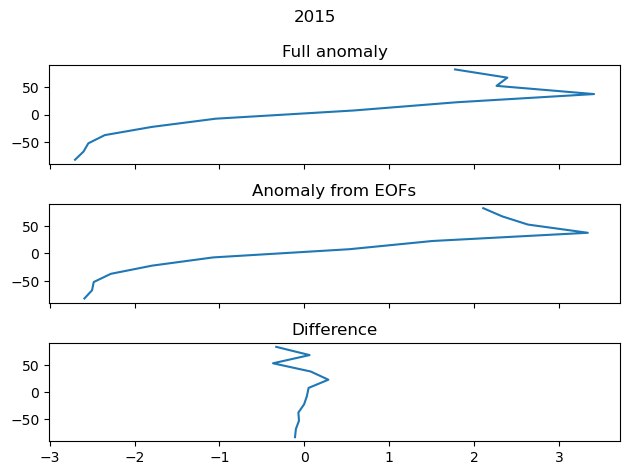

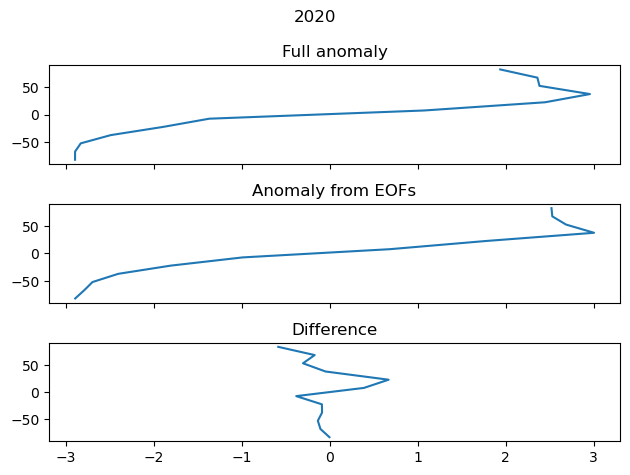

In [17]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [18]:
seasonality, _, lon_mean_ym_monthly_anomalies = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 15605.14it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 20014.80it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 19817.97it/s]

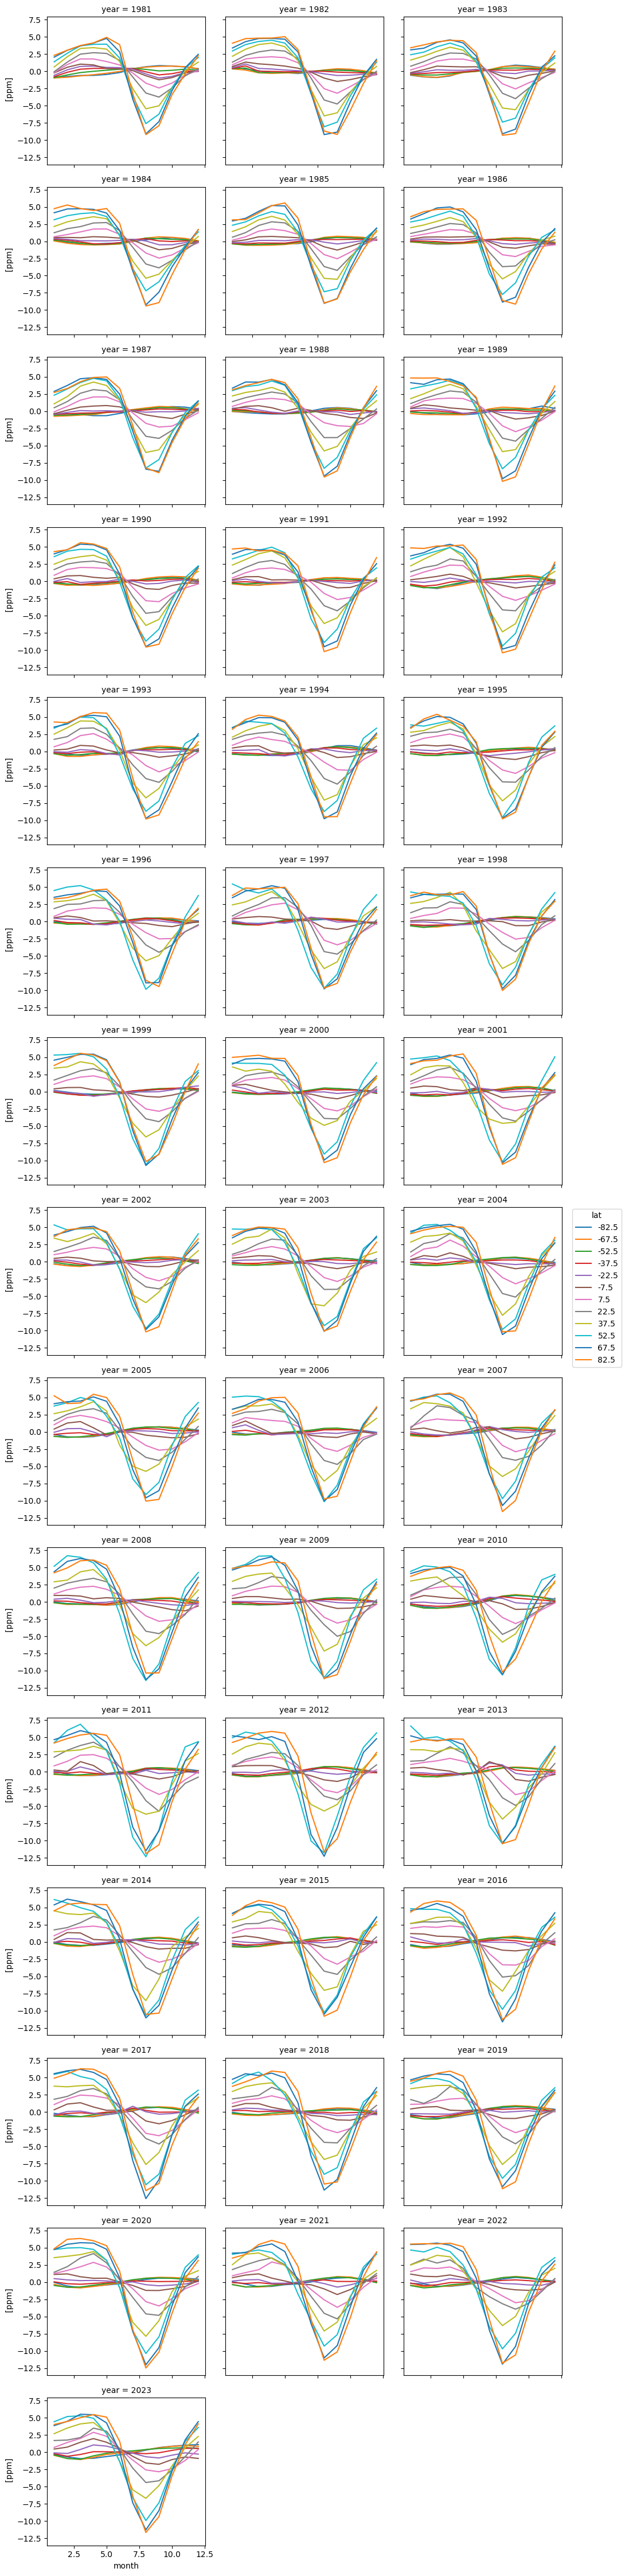

In [19]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

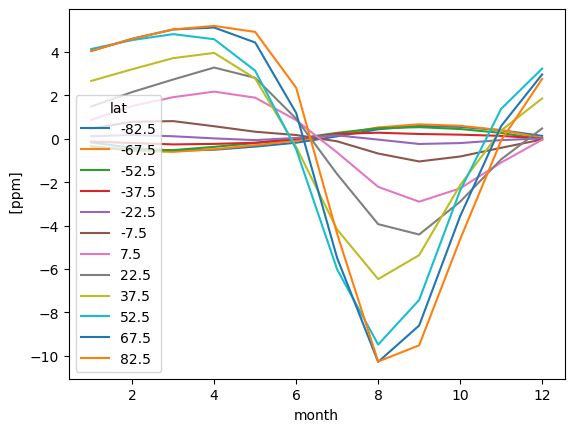

In [20]:
seasonality.plot.line(hue="lat")

In [21]:
(
    seasonality_anomalies,
    seasonality_change_full_eofs_pcs,
) = local.seasonality.calculate_seasonality_change_eofs_pcs(lon_mean, global_mean)
seasonality_change_full_eofs_pcs

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 18857.70it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

...

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 19918.83it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/516 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:00<00:00, 18002.20it/s]

Magnitude,[[0.004200787188956484 -0.061071662589781014 -0.009841815320129064 ... -2.3685094176569105e-05 0.0987310924589177 -0.08401031787568265] [-0.010149144448462287 -0.055786025536372616 -0.025918571147476 ... -0.017911893716557867 0.05276431866841215 -0.050281216286872606] [-0.014555453750241702 -0.04191518163708089 -0.04624287380944958 ... 0.04632508947141436 -0.04292586874717447 0.13123854387362602] ... [-0.005934616002685327 0.234801674114991 0.013328608642755962 ... 0.019859093310860203 -0.11751637276604937 -0.15179453544611146] [0.08694702678150247 0.18074221821278127 -0.02312011021813345 ... 0.0684815477870176 0.07886852318477221 -0.035378068400844474] [0.08926615886618836 0.08487446014348746 0.06866125325479329 ... 0.02450219021932654 0.03214309223294663 -0.011025915692920244]]
Units,ppm
Magnitude,[[-8.448389309470329 3.279804866623945 1.0856168937151958 ... -0.08006150864646462 -0.024487777314800795 -1.918817883043298e-15] [-7.20778036595789 -4.111874893104999 0.7417544018426461 ... 0.031076142848892457 -0.012886557481438424 -1.918817883043302e-15] [-7.641582802336676 1.5072859067033535 0.7153064610179878 ... -0.16148106632912929 0.08020121718043406 -1.9188178830432963e-15] ... [2.528839946309975 0.6033066927439729 2.1807849520549247 ... -0.03510263873366998 0.06127820178818563 -1.918817883043305e-15] [3.858921499441288 0.12762726085630138 2.117967084390291 ... -0.139696867122882 -0.05491285258741769 -1.9188178830432844e-15] [4.054042245710685 2.142979747848561 3.135798771829844 ... 0.06511384110252635 0.06782871161984012 -1.918817883043303e-15]]
Units,dimensionless


<xarray.DataArray (lat: 12, year: 43, month: 12)> Size: 50kB
<Quantity([[[-6.63765965e-01 -3.51334185e-01 -7.30034153e-02 ...  2.03353873e-01
    2.21647268e-01  2.15147067e-01]
  [ 7.43872498e-01  7.45270138e-01  6.07742924e-01 ... -3.71914670e-01
   -5.26222238e-01 -6.12864145e-01]
  [-4.23884830e-01 -4.11365631e-01 -3.72670079e-01 ...  2.12834375e-01
    1.41261089e-01  1.15958694e-01]
  ...
  [ 2.30830448e-01  1.32642541e-01 -1.16404738e-01 ...  1.16594207e-01
    7.39205118e-02 -1.13040480e-01]
  [-1.70286338e-02  1.57295004e-01 -4.29794612e-02 ... -4.37835902e-04
   -5.39562284e-02  4.52088375e-04]
  [-1.35743276e-01 -2.60600701e-01 -3.84893029e-01 ...  3.26069441e-01
    6.28943277e-01  9.71524691e-01]]

 [[-6.29248783e-01 -3.17863475e-01 -7.75302318e-02 ...  1.34979309e-01
    2.67658252e-01  3.24470626e-01]
  [ 6.85815120e-01  7.27218856e-01  3.65408955e-01 ... -3.06284625e-01
   -3.21269764e-01 -2.91922771e-01]
  [-1.75356539e-01 -2.36804520e-01 -2.86533029e-01 ...  5.04522076e-02
    1.03932834e-01  2.51825183e-01]
...
  [ 1.70749272e-01 -3.30413545e-01  1.29444738e-01 ... -2.06125461e-02
    1.16104759e+00  1.35673428e+00]
  [ 1.42793462e+00  9.12342914e-01  6.41218643e-01 ...  4.85557408e-01
    5.87878274e-01  1.54358359e-01]
  [-1.74479165e-01 -1.12796764e-01  4.87522759e-01 ...  8.26998340e-01
    1.21576992e+00  1.48023408e+00]]

 [[-1.74374549e+00 -1.54998349e+00 -1.30006894e+00 ...  1.22231576e+00
   -3.16705562e-01 -5.08502091e-01]
  [ 2.08824506e-02  1.40304914e-01 -2.30610937e-01 ... -1.05726740e+00
   -1.69369813e+00 -1.24529105e+00]
  [-6.36099102e-01 -7.68928651e-01 -7.69460684e-01 ...  1.93882427e-02
    8.84994323e-02  1.54733754e-01]
  ...
  [-5.46616429e-01 -5.66023308e-01  4.32721914e-01 ... -5.21053115e-01
    8.36814433e-01  1.64690150e+00]
  [ 1.48725505e+00  9.86043184e-01  5.21193278e-01 ...  2.83554570e-01
    2.80050175e-01 -1.50548909e-01]
  [-1.22053070e-02 -1.34066721e-01 -2.02969400e-02 ...  1.19545738e+00
    1.18786897e+00  1.35144465e+00]]], 'ppm')>
Coordinates:
  * year     (year) int64 344B 1981 1982 1983 1984 1985 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5

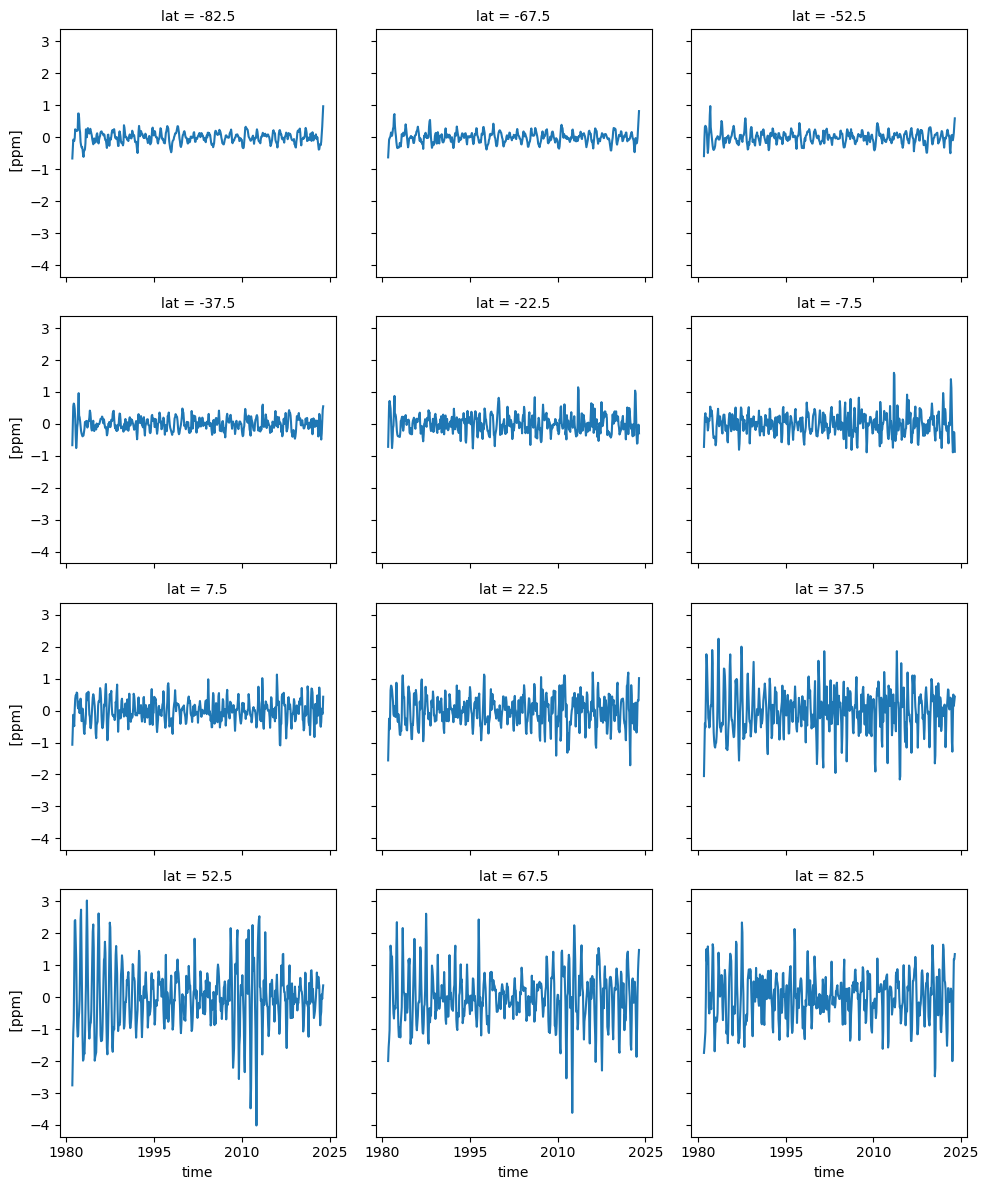

In [22]:
local.xarray_time.convert_year_month_to_time(seasonality_anomalies).plot.line(col="lat", col_wrap=3)
seasonality_anomalies

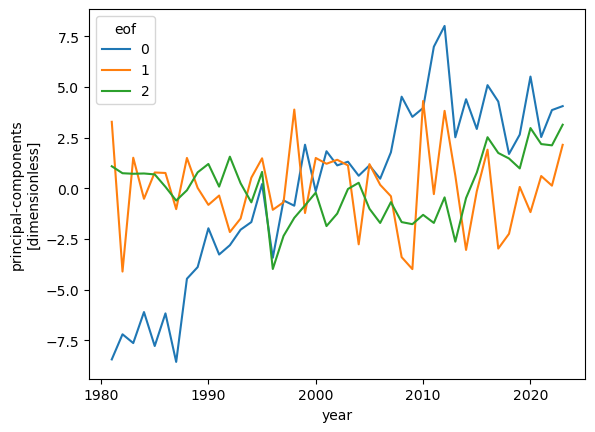

In [23]:
n_eofs_to_show = 3
(seasonality_change_full_eofs_pcs["principal-components"].sel(eof=range(n_eofs_to_show)).plot.line(hue="eof"))

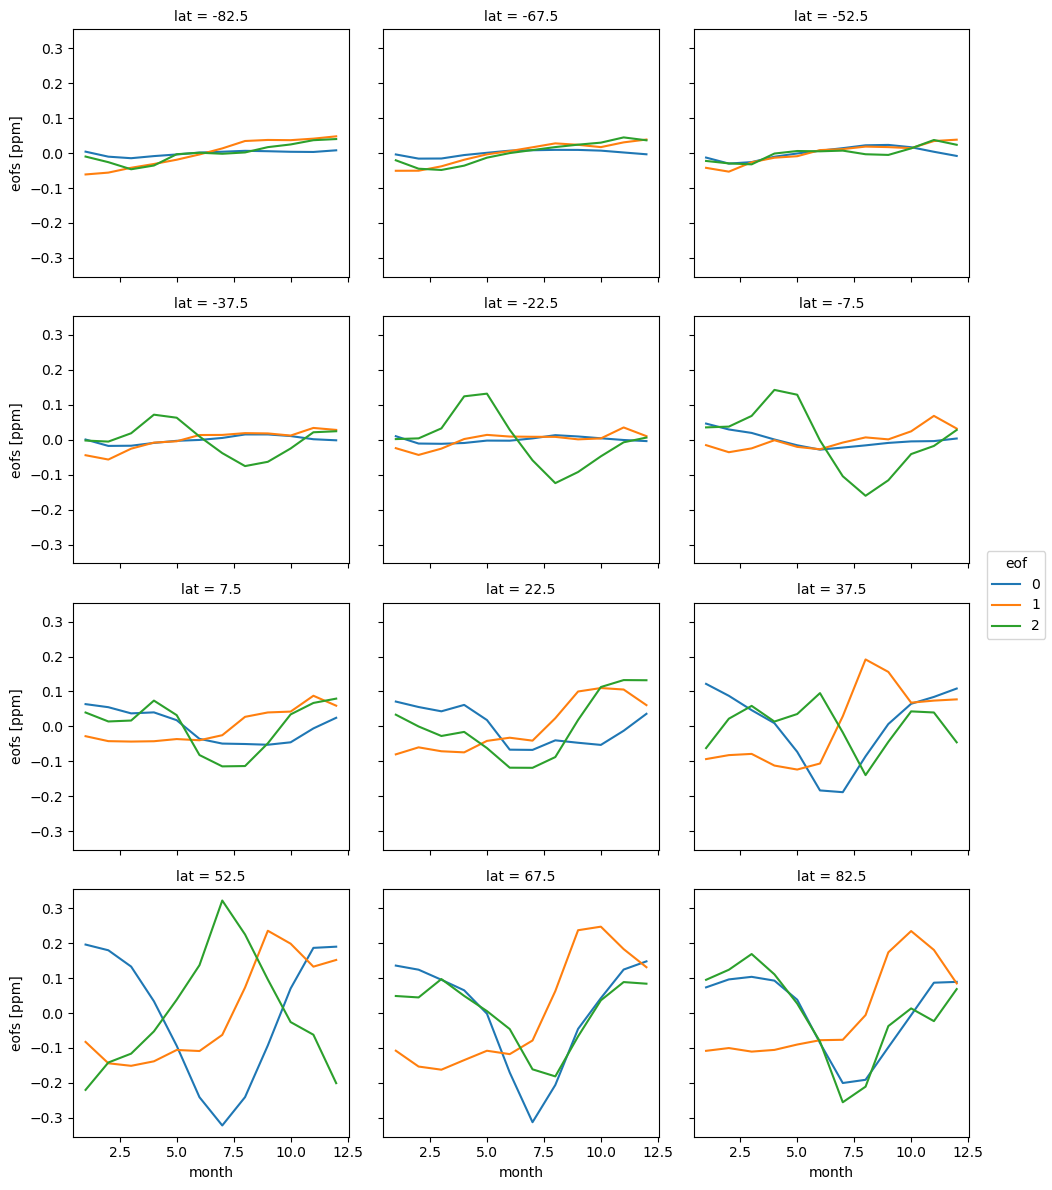

In [24]:
(
    seasonality_change_full_eofs_pcs["eofs"]
    .unstack("lat-month")
    .sel(eof=range(n_eofs_to_show))
    .plot.line(hue="eof", col="lat", col_wrap=3)
)

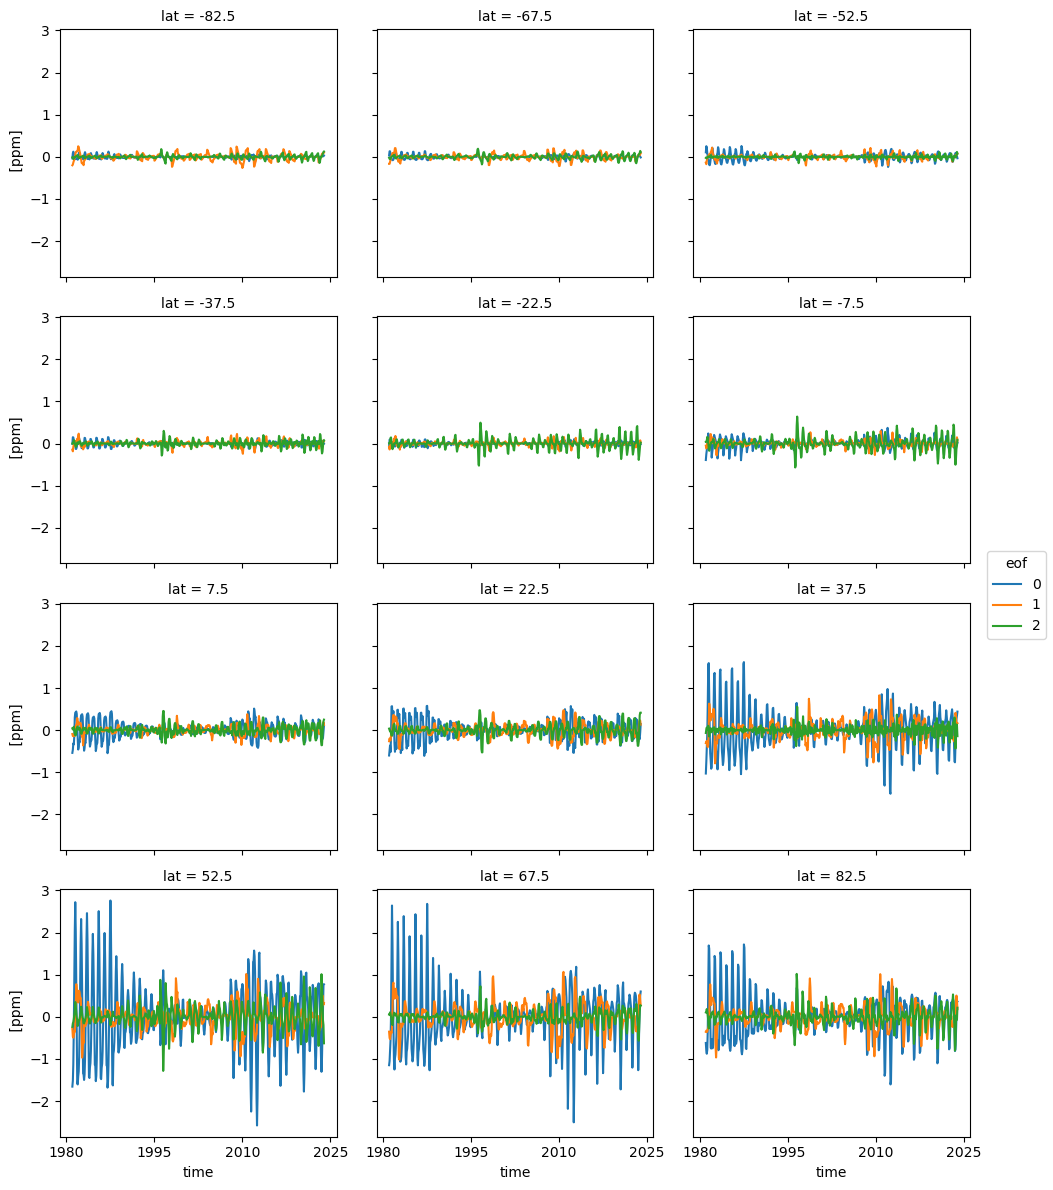

In [25]:
eof_based_anomalies = local.xarray_time.convert_year_month_to_time(
    (
        seasonality_change_full_eofs_pcs["principal-components"] * seasonality_change_full_eofs_pcs["eofs"]
    ).unstack("lat-month")
)
(eof_based_anomalies.sel(eof=range(n_eofs_to_show)).plot.line(hue="eof", col="lat", col_wrap=3))

In [26]:
seasonality_change_eofs_pcs = seasonality_change_full_eofs_pcs.sel(
    eof=range(config_step.seasonality_change_n_eofs_to_use),
)
seasonality_change_eofs_pcs

Magnitude,[[0.004200787188956484] [-0.010149144448462287] [-0.014555453750241702] [-0.008518519591661078] [-0.0038084449949983556] [0.0015516709807955693] [0.004011410852796488] [0.0066049569161054575] [0.005455775550594557] [0.0038370153756936832] [0.0033217633604819647] [0.008048412087736516] [-0.003813357863191492] [-0.015736342919797267] [-0.015416438932829193] [-0.005512150461818064] [0.0009368741028855893] [0.00705632623009416] [0.008231968943754596] [0.009378428237683771] [0.009218433325127137] [0.007131926377056381] [0.0018463456642353385] [-0.0033217612048648563] [-0.012723183583927041] [-0.030015453578080133] [-0.025684332296317548] [-0.010315371668997242] [-0.0010074966620193422] [0.006882223122370703] [0.014211362092602584] [0.0224188240780778] [0.02351006597529157] [0.016888995867390837] [0.0038743764884393277] [-0.008039811397586055] [0.0007370490716892465] [-0.017597452288442225] [-0.017063251360386757] [-0.008991960486357215] [-0.0029845085335313756] [-0.0004626650506136561] [0.005225324365946439] [0.015214897787388758] [0.01524183703627152] [0.010665375777428774] [0.0015370492034393617] [-0.0015215101589910343] [0.010202266632504361] [-0.010800206632082886] [-0.011558184180062644] [-0.009210205947219038] [-0.0023528224597277017] [-0.0026438218443953993] [0.003944670545643293] [0.01317870486958088] [0.009456188015833733] [0.004239353692484787] [-0.0006499210507010432] [-0.0038059335666004632] [0.04632553482317954] [0.029488708054586275] [0.019598313416887354] [0.0007800413398017221] [-0.015780861148305857] [-0.02827428598026653] [-0.022279935844817786] [-0.016011011224883038] [-0.008984280409509379] [-0.004651575425084061] [-0.0038102239025934606] [0.0035995881363072913] [0.06379741041969815] [0.05501880493276163] [0.03734811895557013] [0.04020622369694015] [0.017795935549551542] [-0.03562162969243313] [-0.04915813014876787] [-0.05039283339862896] [-0.052481887009473024] [-0.04549763894918835] [-0.005728793389079505] [0.024714516303831785] [0.07118287403135662] [0.05553116323103778] [0.04325891524130703] [0.061617883372439196] [0.018217594479479637] [-0.06659171813188253] [-0.06722738551795744] [-0.039863080089778985] [-0.046812891968343665] [-0.052948030697668624] [-0.012462701937959004] [0.036097486156288966] [0.12182513963346352] [0.08762936319869978] [0.04658080791152114] [0.009308694648401507] [-0.07275208290404085] [-0.1832926733709645] [-0.18830284107327025] [-0.08556203131462699] [0.006848925088064385] [0.0648089153715204] [0.08444451622328954] [0.10846341823053145] [0.1961220169695092] [0.17977863424293714] [0.13308041965230769] [0.03377719450459981] [-0.0936991937878084] [-0.24096428211757012] [-0.32187345139180995] [-0.24063146122865528] [-0.09263687482193474] [0.07032097856082614] [0.18665744724296696] [0.19006862406736472] [0.1359161249571294] [0.1241778144862185] [0.09536034021346418] [0.06514735951345428] [-0.0018692306765028452] [-0.1702972354581949] [-0.31252810445932316] [-0.20595301434906468] [-0.045313307251242683] [0.04274468124382565] [0.12457144699702265] [0.14804339012981396] [0.07357219576595192] [0.09634071762514099] [0.10374128219273218] [0.09284978310532996] [0.038141070984567926] [-0.08568009369276812] [-0.20029543562732988] [-0.19107522886994588] [-0.09787247237255348] [-0.005934616002685327] [0.08694702678150247] [0.08926615886618836]]
Units,ppm
Magnitude,[[-8.448389309470329] [-7.20778036595789] [-7.641582802336676] [-6.111287485012081] [-7.786569367487797] [-6.176694029405333] [-8.572251564164931] [-4.467031044686843] [-3.892265412839174] [-1.9754485645210944] [-3.2702878078143454] [-2.8119766597292273] [-2.04562912294732] [-1.669530821099349] [0.20864479234105024] [-3.4306823245505202] [-0.6006219761581261] [-0.8621346517702358] [2.14966642238909] [-0.14840245724376344] [1.8268156465334235] [1.1281325057998945] [1.3107664021933685] [0.6179007061166677] [1.1289057932124835] [0.4710089633358845] [1.773690166069412] [4.519284282471136] [3.523380881180639] [3.9612643362080333] [6.9

In [27]:
seasonality_change_from_eofs = xr.dot(
    seasonality_change_eofs_pcs["principal-components"],
    seasonality_change_eofs_pcs["eofs"],
    dim="eof",
)
seasonality_change_from_eofs

Magnitude,[[-0.035489885578539875 0.08574392345865893 0.1229701398580318 ... 0.05013794639289825 -0.7345623315510759 -0.7541552622625858] [-0.030278351422127984 0.07315280408689699 0.10491251375860028 ... 0.042775408703654795 -0.6266950725141284 -0.6434108672201903] [-0.0321006631394061 0.07755552767580016 0.11122670505805386 ... 0.04534985958459222 -0.6644129045678356 -0.6821347444225185] ... [0.010623118449380346 -0.02566556190214155 -0.03680841288027855 ... -0.01500769401360108 0.21987511453794667 0.22573982839446946] [0.01621050799804171 -0.039164751713106315 -0.05616835341093102 ... -0.022901217283690725 0.3355217509596373 0.3444710996212758] [0.01703016872926982 -0.04114506035188618 -0.05900842440896788 ... -0.02405918398695699 0.3524869197111493 0.361888779155849]]
Units,ppm


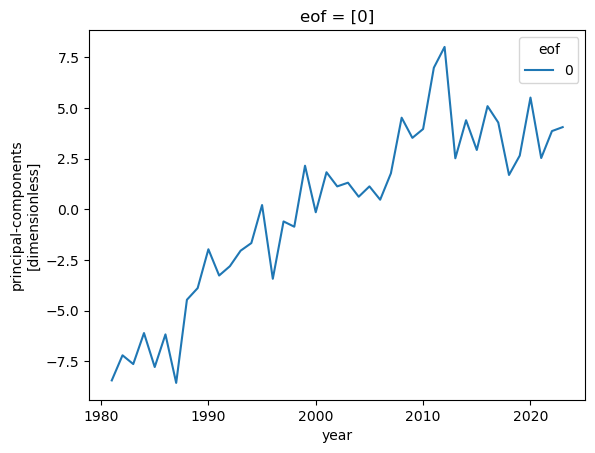

In [28]:
(seasonality_change_eofs_pcs["principal-components"].plot.line(hue="eof"))

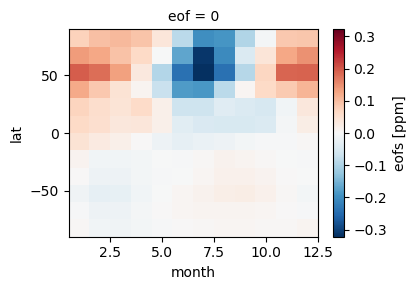

In [29]:
(seasonality_change_eofs_pcs["eofs"].unstack("lat-month").plot.pcolormesh(y="lat", x="month", col="eof"))

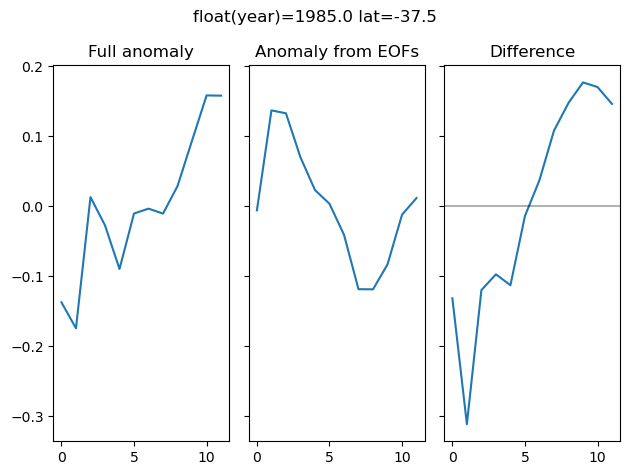

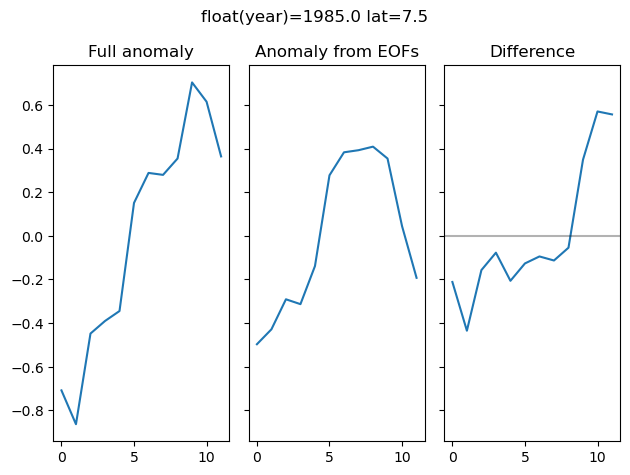

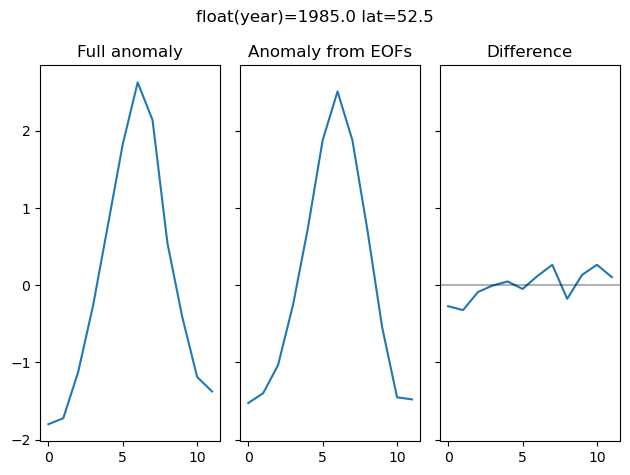

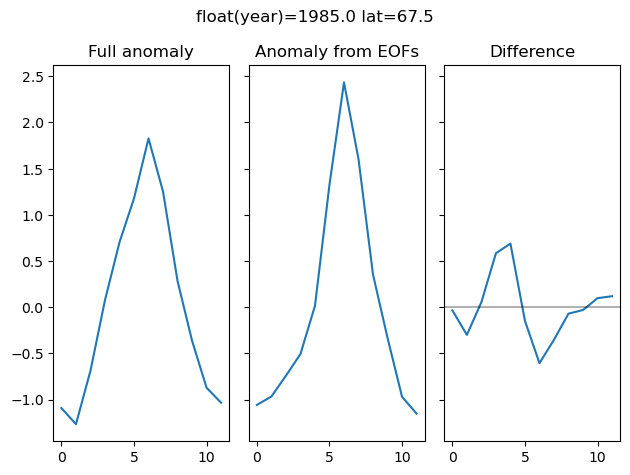

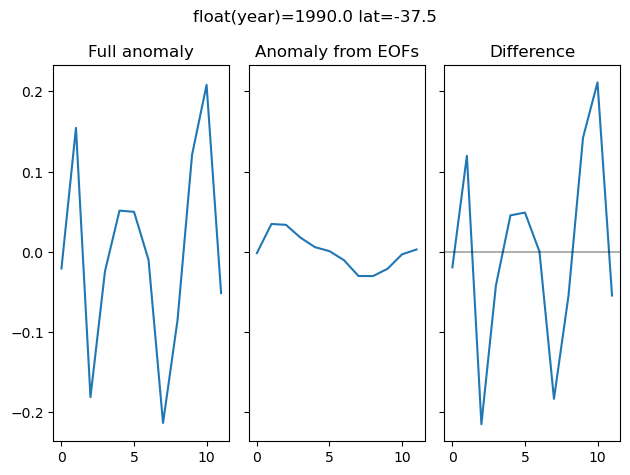

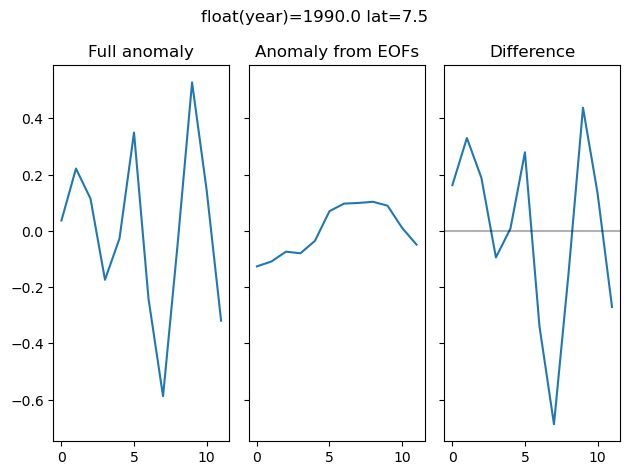

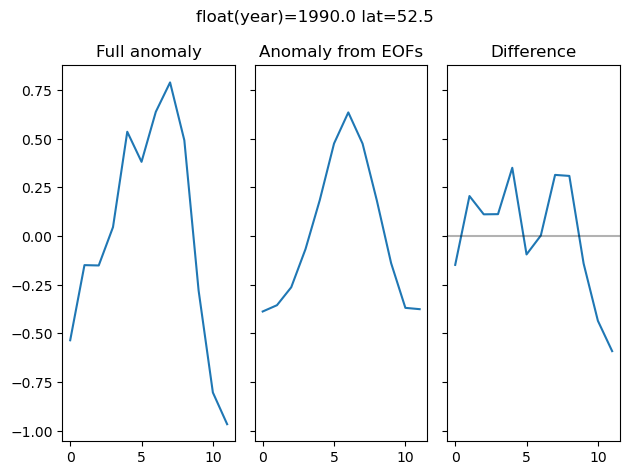

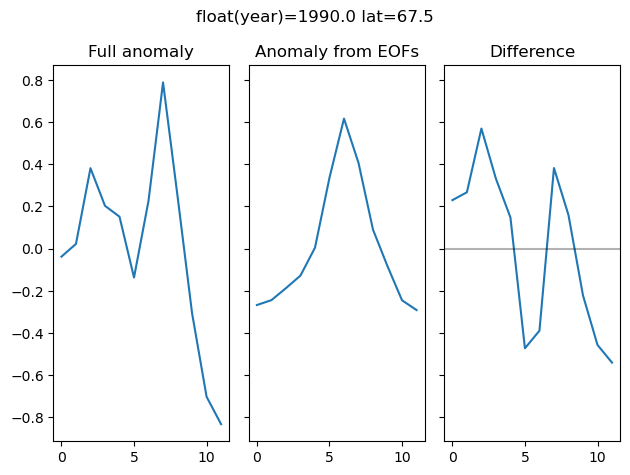

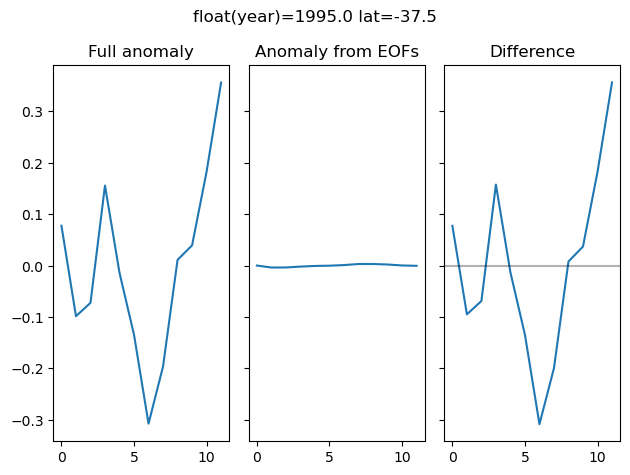

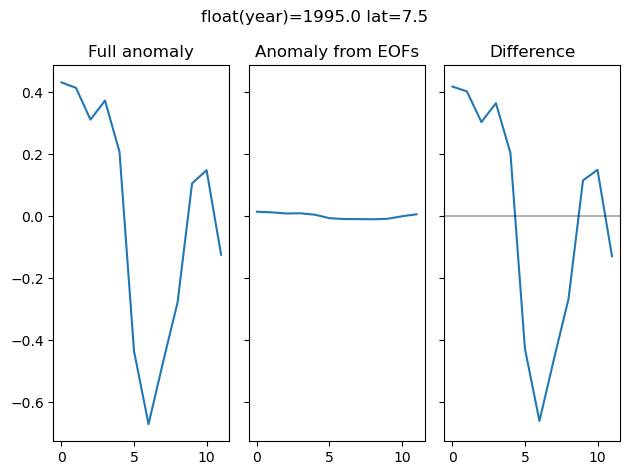

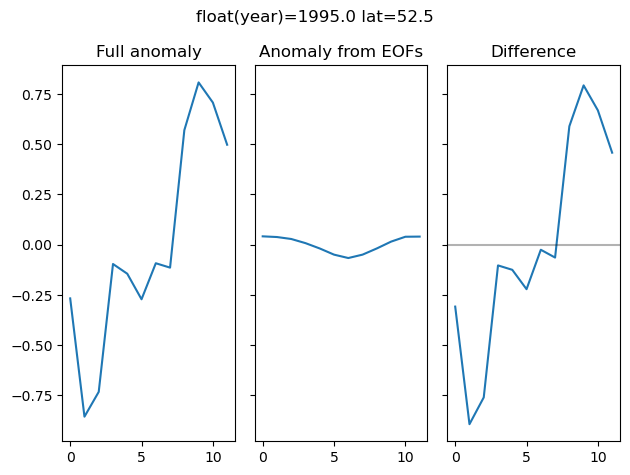

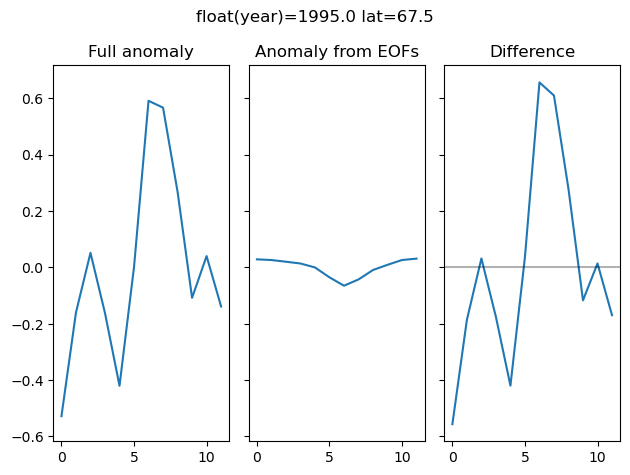

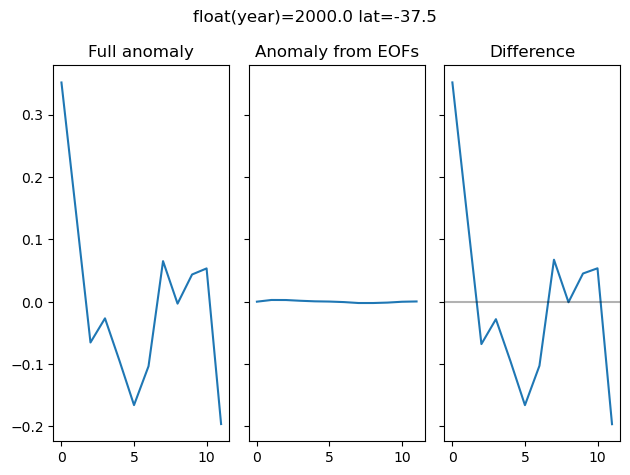

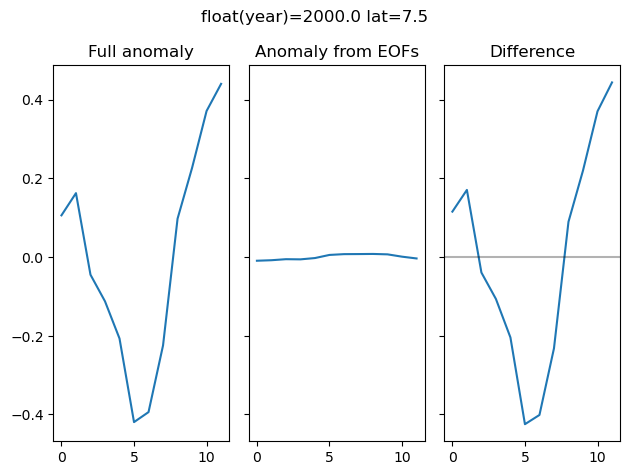

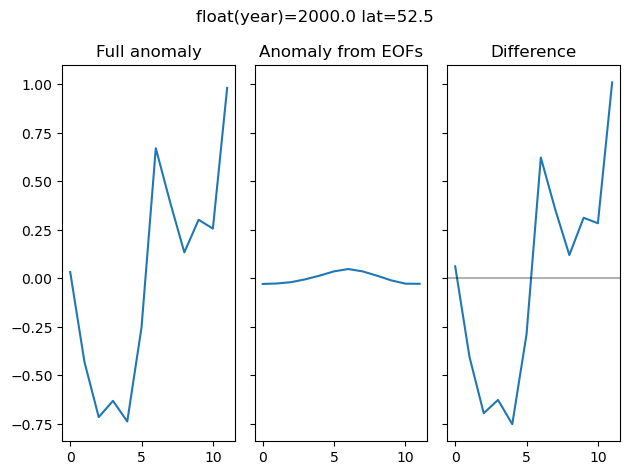

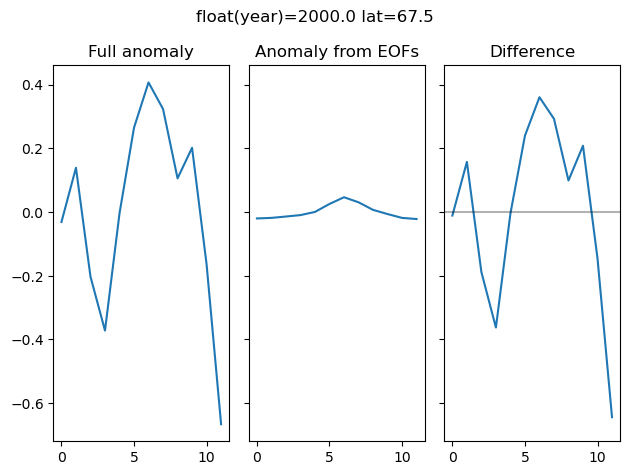

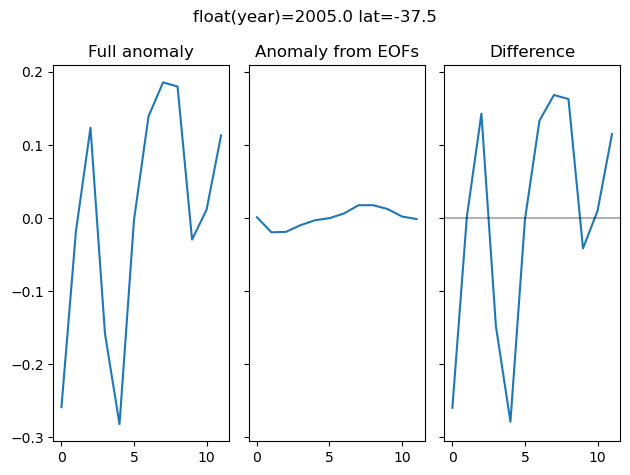

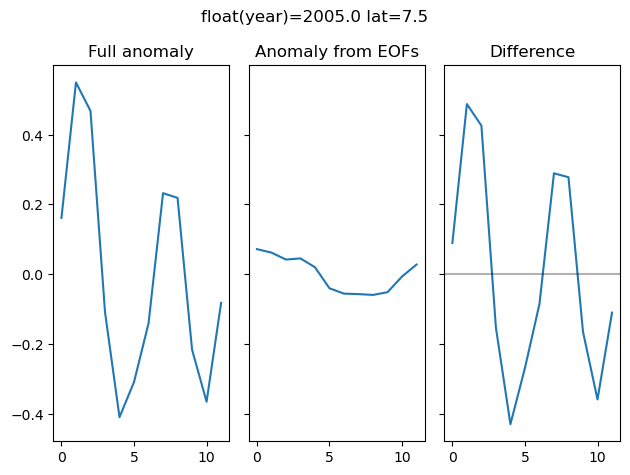

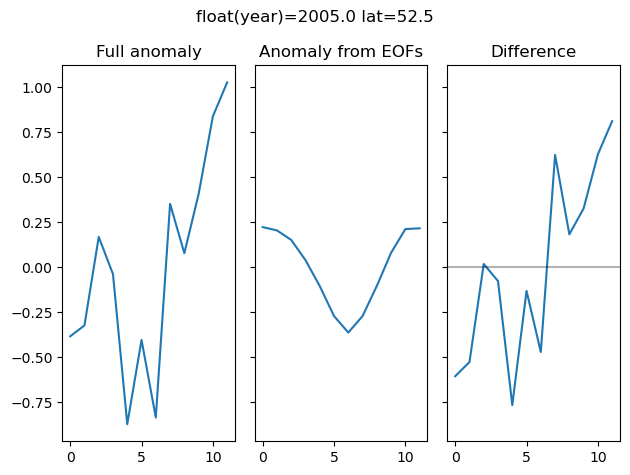

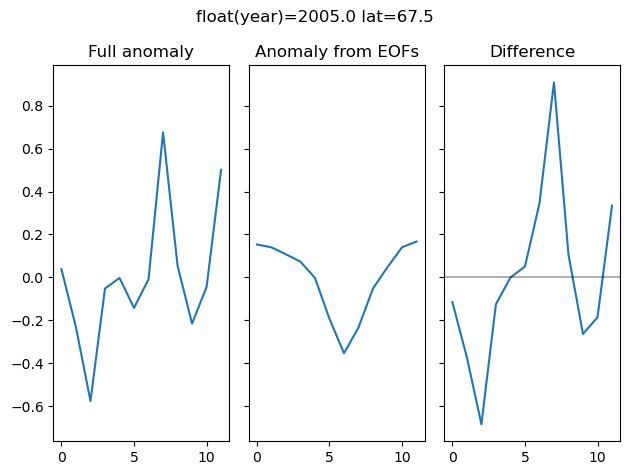

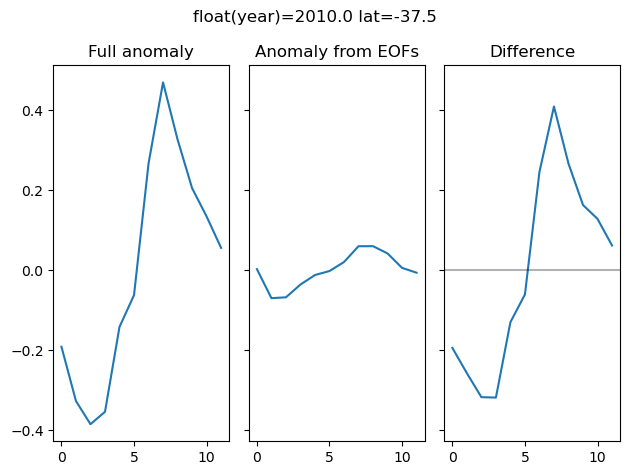

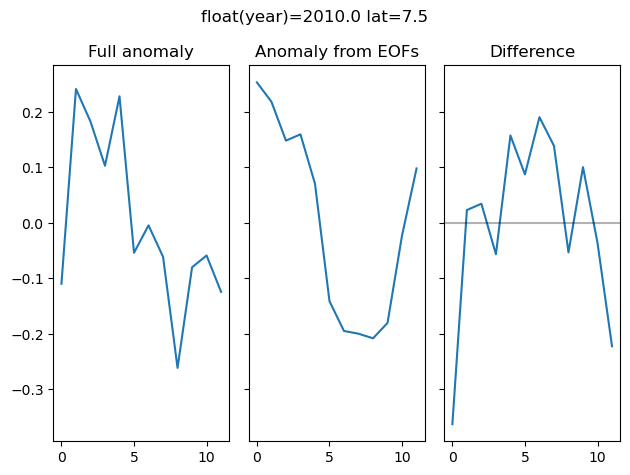

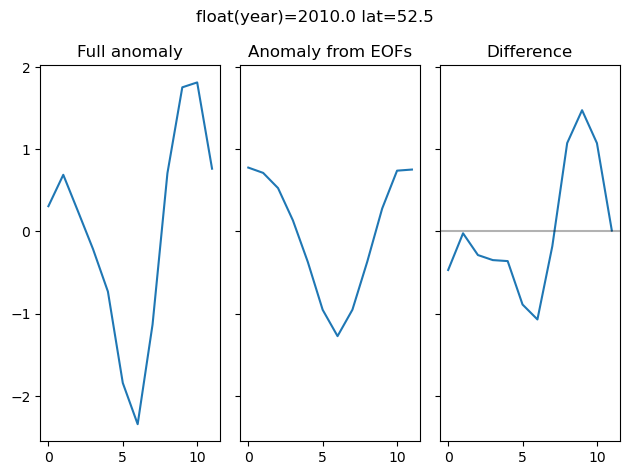

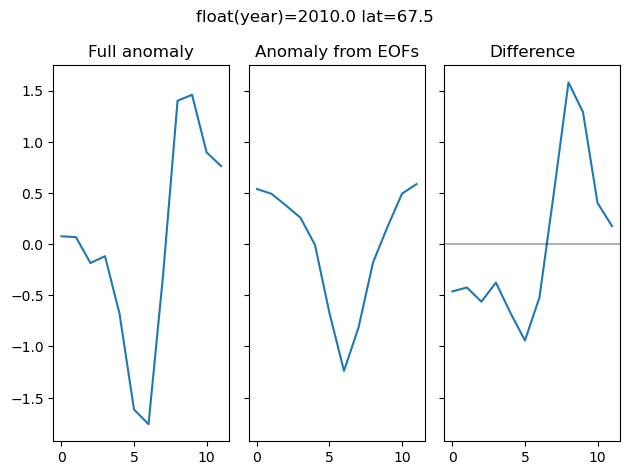

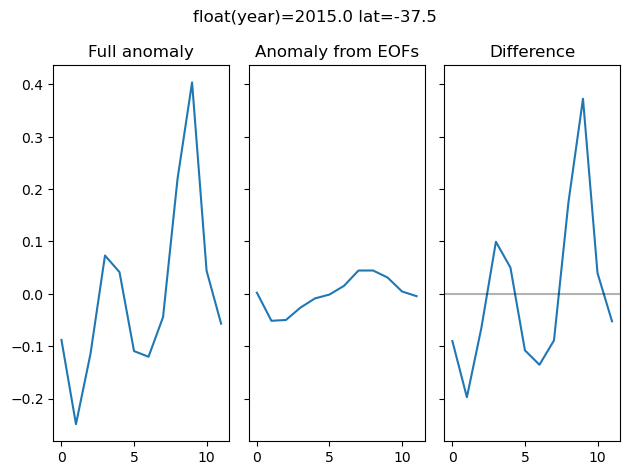

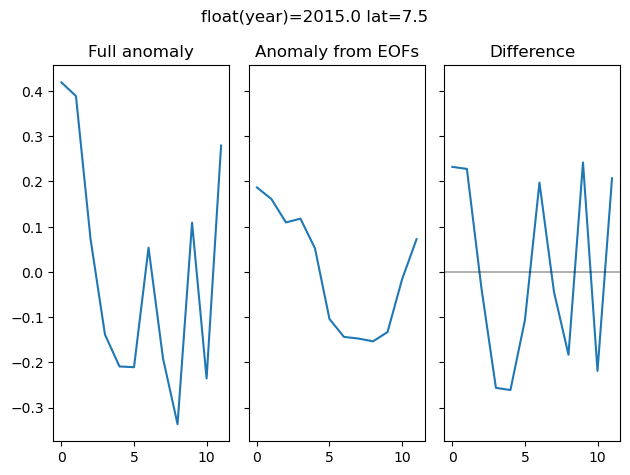

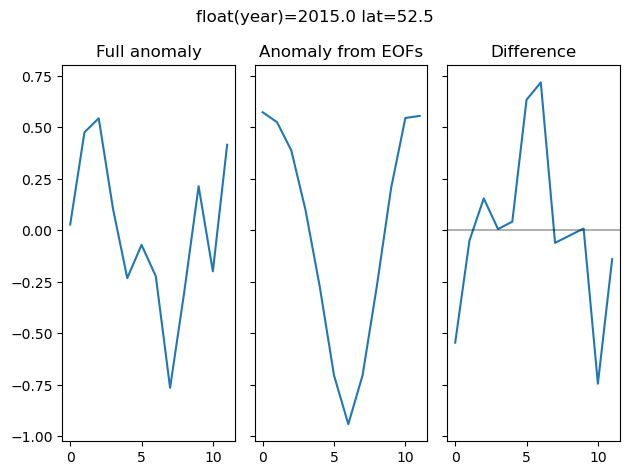

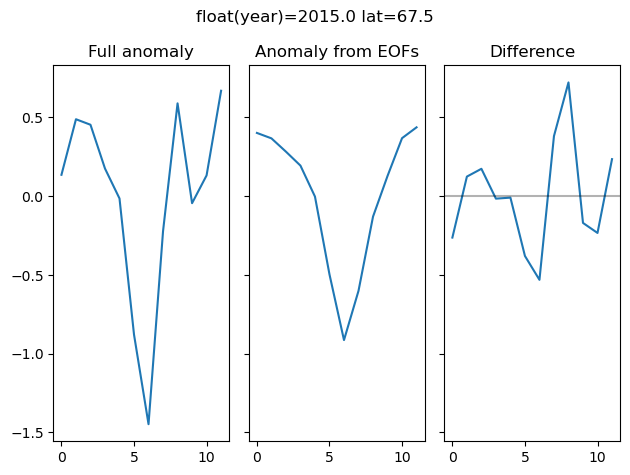

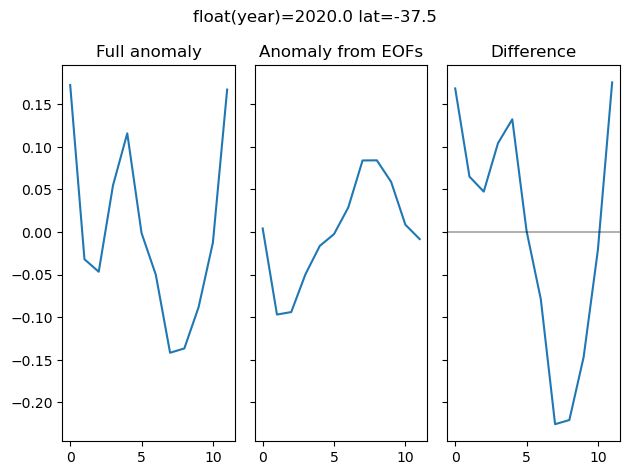

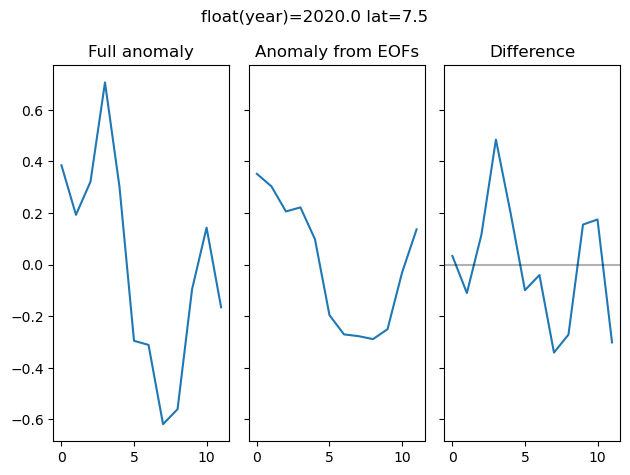

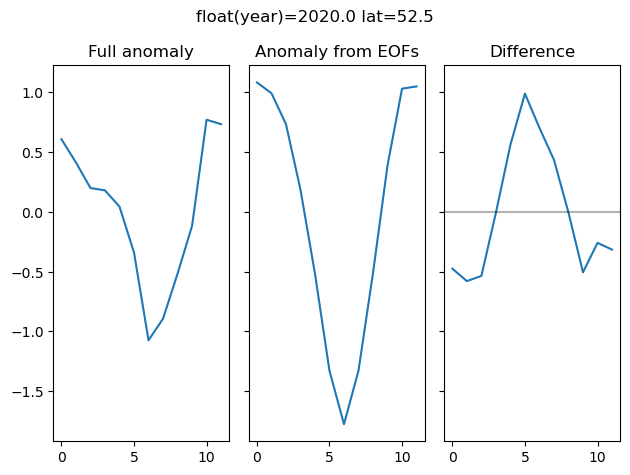

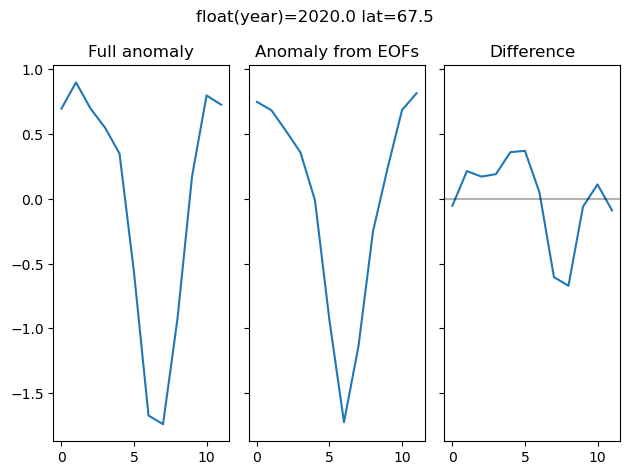

In [30]:
for year in seasonality_change_from_eofs["year"]:
    if year % 5:
        continue

    for lat in [-37.5, 7.5, 52.5, 67.5]:
        fig, axes = plt.subplots(ncols=3, sharex=True, sharey=True)
        if isinstance(axes, matplotlib.axes.Axes):
            raise TypeError(type(axes))

        selected = seasonality_anomalies.sel(year=year, lat=lat)
        axes[0].plot(selected.data.m)
        axes[0].set_title("Full anomaly")

        selected_eofs = seasonality_change_from_eofs.sel(year=year, lat=lat)
        axes[1].plot(selected_eofs.data.m)
        axes[1].set_title("Anomaly from EOFs")

        axes[2].plot(selected.data.m - selected_eofs.data.m)
        axes[2].axhline(0, color="k", alpha=0.3)
        axes[2].set_title("Difference")

        # axes[0].set_ylim([-90, 90])

        plt.suptitle(f"{float(year)=} {lat=}")
        plt.tight_layout()
        plt.show()

        # break
    # break

### Save

In [31]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[340.41841524741864 340.8898303109085 342.39885069815256 344.06265671648015 345.5184583462482 347.00121114937195 348.7715769996939 351.2754612537245 352.8699075105913 354.0914861354658 355.40912368466803 356.30032252212226 357.0166270959333 358.370066213528 360.33215202440806 362.12592764458645 363.35349381242787 366.07816847298403 367.9341462761768 369.2326123405019 370.80002275769425 372.90811111454974 375.4381052498998 377.09990751380724 379.01912894024855 381.1603389630507 382.76298465768406 384.927932382924 386.4896998114968 388.90119278134506 391.0921633133191 393.2440375168851 395.94573536207764 397.8326799296954 400.1363097826533 403.2492569508209 405.2739484544132 407.76275380672223 410.3671897526088 412.8736931180183 415.12597139417943 417.32025724171285 419.6866820727719]
Units,ppm


In [32]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3398549235667994 -0.2279518542202384] [0.3280249642550779 -0.21667814452529127] [0.3240928653441622 -0.11290118149536105] [0.29643637000091805 0.001162345511583901] [0.23146558727475253 0.11844135697646926] [0.13696989509884952 0.20319759722792471] [-0.0713614960427211 0.174397046007536] [-0.19958442222557185 0.2667222315807009] [-0.4242643004612816 -0.7221899732016387] [-0.34060660505423995 -0.12186793264806786] [-0.3042778672164788 0.10852869951757736] [-0.279510277857286 0.42811117709708046]]
Units,ppm
Magnitude,[[-3.4078559757362656 1.3728705809672521] [-3.0718928926968796 1.080944204165597] [-2.9148521501787985 0.8886287181528333] [-3.389224313579394 0.9345832823250398] [-3.5797363227564327 0.7671336820172274] [-4.222134676615504 0.9441732209243293] [-3.220898661371553 1.0383549537628198] [-4.531214183272495 1.2310945088122962] [-4.951772992913496 1.5677083013287625] [-4.538514865693663 1.2804213657427] [-5.173706470749861 1.2338640592569938] [-4.273103707637795 0.8496375674941062] [-3.965108611258437 0.6241795767995816] [-5.042210471999207 0.459726569836758] [-5.111975184252345 0.6019809645460302] [-6.008421371790536 0.3424537649315777] [-5.36418297137572 0.35681607952608585] [-5.492211705600382 0.6138119587480596] [-6.070957788177195 -0.059653030130348075] [-6.392679427617976 -0.16228148585739732] [-6.3834000533068505 -0.45827770761568964] [-6.116260991320756 -0.5048325325708336] [-6.957893832419071 -0.3820759214669319] [-6.347658054708406 -0.6213875357467776] [-6.846471859965717 -0.7524881659932885] [-7.551205937839135 -0.7686209282608008] [-6.705257602735117 -1.3241931223382695] [-7.301377545919926 -1.1342376935890761] [-6.888449225143301 -1.0418218293248094] [-8.483601605052062 -1.7004306283376365] [-8.614714835190084 -1.1307825171650858] [-8.537130218880705 -0.6086678103421533] [-8.305819625835335 -0.2548015726615268] [-8.226966271201903 -0.3595563980313965] [-7.689675133590265 -0.10292169544148298] [-7.679706725149857 0.06957983323397103] [-8.859902121453993 0.11975459474699837] [-8.09737915282875 0.08563958690373405] [-7.8006602845076145 0.37368035213824286] [-8.101679825965508 0.5991512005844014] [-9.1172598635361 0.14862754294515435] [-8.939469815800466 0.1303478895442889] [-8.590944383639819 0.4360138174509567]]
Units,dimensionless


Use absolute seasonality plus seasonality change for CO2

In [33]:
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
seasonality

Magnitude,[[-0.17158756434653083 -0.42111771661134534 -0.5485749812849801 -0.5084979046040972 -0.36380440277634646 -0.18476945614711068 0.10998678745419231 0.4340148913464566 0.5874921291424312 0.5460088162043599 0.39058590905334223 0.13026333545474245] [-0.35684873773389925 -0.5659023942052439 -0.6035288215924052 -0.4846395565127063 -0.29808805826576057 -0.09289585651213544 0.19623127803299137 0.5192848309965759 0.6610782417174037 0.5941872992050943 0.39187687864670334 0.03924465005627156] [-0.35272174060122946 -0.5166704142294798 -0.523865153572915 -0.37509394456503875 -0.19854462489571645 0.0036113837084586035 0.27025711917005885 0.48091658581573127 0.5313085892364214 0.4464314080419634 0.26703165040956045 -0.032661206734191144] [-0.13088919934957075 -0.19873939597492254 -0.26219616805193774 -0.23865538254924717 -0.18590903152349436 -0.01564970890249401 0.21902997875245117 0.27586389660255434 0.21741134394898287 0.18615294716446468 0.1304028015320529 0.003177565580924323] [0.11728008387633561 0.17018262373008694 0.11207861962593545 0.014633320382999903 -0.06526318694658834 0.03487149915693059 0.15289057830875927 -0.0412048855376714 -0.24203713479970157 -0.20142399941174824 -0.06659281998672219 0.014584535757748209] [0.46965764682437205 0.7798216500455677 0.8095017950613418 0.5735226654807873 0.3208652797921472 0.16976814279289715 -0.12064708148556012 -0.6820827806952702 -1.0468302003411187 -0.819336149874343 -0.41906278535782215 -0.03517937600732366] [0.8586460319482531 1.504154587294341 1.9113554216019017 2.1670750430073706 1.8884347456885373 0.8544237361947254 -0.6346902113352217 -2.2166728383902234 -2.898976519514777 -2.2863301996464176 -1.0995028003583969 -0.04791782230181472] [1.482695427952772 2.147478534590111 2.725764536873225 3.2754356830839964 2.8018069005071324 0.9217539390240277 -1.6307009602650657 -3.9331350137449115 -4.410138437790484 -2.9009294199520355 -0.9531090780897962 0.4730771758017129] [2.6601524733826643 3.1972853800155114 3.7089184728815225 3.948490762532584 2.7724344728344756 -0.37743687784718716 -4.181385444718427 -6.4631978381205535 -5.360270074605418 -2.134973005197628 0.3798295062374643 1.8501514475660044] [4.128378674448143 4.541715259409676 4.813338270950534 4.579218660662789 3.1301715406377713 -0.4878658523103248 -6.015417044229732 -9.476796343543434 -7.425587221922878 -2.3858695454805985 1.373478813947955 3.2252334396027664] [4.039058930645094 4.599681880809443 5.029569607979166 5.117367090495011 4.429021047253433 1.1865796188938773 -5.492773291759542 -10.275239846324318 -8.600840208530464 -3.570888856668455 0.5807897508862657 2.957673802263842] [4.042912594537712 4.594296997339329 5.028142093959126 5.191750406389506 4.916094913553573 2.346675811862199 -4.383412145137967 -10.256498178459395 -9.511854667151928 -4.632316989623158 -0.08791412357040536 2.752123203761606]]
Units,ppm


In [34]:
config_step.observational_network_seasonality_change_eofs_file.parent.mkdir(exist_ok=True, parents=True)
to_save = seasonality_change_eofs_pcs.unstack("lat-month")
to_save.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_change_eofs_file)
to_save

Magnitude,[[[0.004200787188956484 -0.010149144448462287 -0.014555453750241702 -0.008518519591661078 -0.0038084449949983556 0.0015516709807955693 0.004011410852796488 0.0066049569161054575 0.005455775550594557 0.0038370153756936832 0.0033217633604819647 0.008048412087736516] [-0.003813357863191492 -0.015736342919797267 -0.015416438932829193 -0.005512150461818064 0.0009368741028855893 0.00705632623009416 0.008231968943754596 0.009378428237683771 0.009218433325127137 0.007131926377056381 0.0018463456642353385 -0.0033217612048648563] [-0.012723183583927041 -0.030015453578080133 -0.025684332296317548 -0.010315371668997242 -0.0010074966620193422 0.006882223122370703 0.014211362092602584 0.0224188240780778 0.02351006597529157 0.016888995867390837 0.0038743764884393277 -0.008039811397586055] [0.0007370490716892465 -0.017597452288442225 -0.017063251360386757 -0.008991960486357215 -0.0029845085335313756 -0.0004626650506136561 0.005225324365946439 0.015214897787388758 0.01524183703627152 0.010665375777428774 0.0015370492034393617 -0.0015215101589910343] [0.010202266632504361 -0.010800206632082886 -0.011558184180062644 -0.009210205947219038 -0.0023528224597277017 -0.0026438218443953993 0.003944670545643293 0.01317870486958088 0.009456188015833733 0.004239353692484787 -0.0006499210507010432 -0.0038059335666004632] [0.04632553482317954 0.029488708054586275 0.019598313416887354 0.0007800413398017221 -0.015780861148305857 -0.02827428598026653 -0.022279935844817786 -0.016011011224883038 -0.008984280409509379 -0.004651575425084061 -0.0038102239025934606 0.0035995881363072913] [0.06379741041969815 0.05501880493276163 0.03734811895557013 0.04020622369694015 0.017795935549551542 -0.03562162969243313 -0.04915813014876787 -0.05039283339862896 -0.052481887009473024 -0.04549763894918835 -0.005728793389079505 0.024714516303831785] [0.07118287403135662 0.05553116323103778 0.04325891524130703 0.061617883372439196 0.018217594479479637 -0.06659171813188253 -0.06722738551795744 -0.039863080089778985 -0.046812891968343665 -0.052948030697668624 -0.012462701937959004 0.036097486156288966] [0.12182513963346352 0.08762936319869978 0.04658080791152114 0.009308694648401507 -0.07275208290404085 -0.1832926733709645 -0.18830284107327025 -0.08556203131462699 0.006848925088064385 0.0648089153715204 0.08444451622328954 0.10846341823053145] [0.1961220169695092 0.17977863424293714 0.13308041965230769 0.03377719450459981 -0.0936991937878084 -0.24096428211757012 -0.32187345139180995 -0.24063146122865528 -0.09263687482193474 0.07032097856082614 0.18665744724296696 0.19006862406736472] [0.1359161249571294 0.1241778144862185 0.09536034021346418 0.06514735951345428 -0.0018692306765028452 -0.1702972354581949 -0.31252810445932316 -0.20595301434906468 -0.045313307251242683 0.04274468124382565 0.12457144699702265 0.14804339012981396] [0.07357219576595192 0.09634071762514099 0.10374128219273218 0.09284978310532996 0.038141070984567926 -0.08568009369276812 -0.20029543562732988 -0.19107522886994588 -0.09787247237255348 -0.005934616002685327 0.08694702678150247 0.08926615886618836]]]
Units,ppm
Magnitude,[[-8.448389309470329] [-7.20778036595789] [-7.641582802336676] [-6.111287485012081] [-7.786569367487797] [-6.176694029405333] [-8.572251564164931] [-4.467031044686843] [-3.892265412839174] [-1.9754485645210944] [-3.2702878078143454] [-2.8119766597292273] [-2.04562912294732] [-1.669530821099349] [0.20864479234105024] [-3.4306823245505202] [-0.6006219761581261] [-0.8621346517702358] [2.14966642238909] [-0.14840245724376344] [1.8268156465334235] [1.1281325057998945] [1.3107664021933685] [0.6179007061166677] [1.1289057932124835] [0.4710089633358845] [1.773690166069412] [4.519284282471136] [3.523380881180639] [3.9612643362080333] [6.986235730409714] [8.012609931334143] [2.515315451797805] [4.394308643350135] [2.9263279059968865] [5.089107369049445] [4.280080218172309] [1.6923265372244087] [2.647520113495585] [5.513469277051585] [2.528839946309975] [3.858921499441288] [4.054042245710685]]
Uni